# scikit-learn Classification with Iris Dataset

**scikit-learn** (sklearn) is a popular Python library providing simple and efficient tools for data mining and machine learning.

The **Iris dataset** is a classic benchmark: 150 samples of iris flowers across 3 species (Setosa, Versicolor, Virginica), each with 4 features (sepal length, sepal width, petal length, petal width in cm).

We will:
1. Load & explore the data
2. Split into train/test sets
3. Train a classifier
4. Evaluate performance
5. Experiment with preprocessing and pipelines
6. Compare multiple models

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


---
## 1. Load and Explore the Iris Dataset

In [2]:
iris = load_iris()
X = iris.data       # features (150 x 4)
y = iris.target     # labels (0, 1, 2)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Target distribution:", np.bincount(y))

Feature matrix shape: (150, 4)
Target vector shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Target distribution: [50 50 50]


In [3]:
# Create a DataFrame for easier inspection
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [4]:
# Basic statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


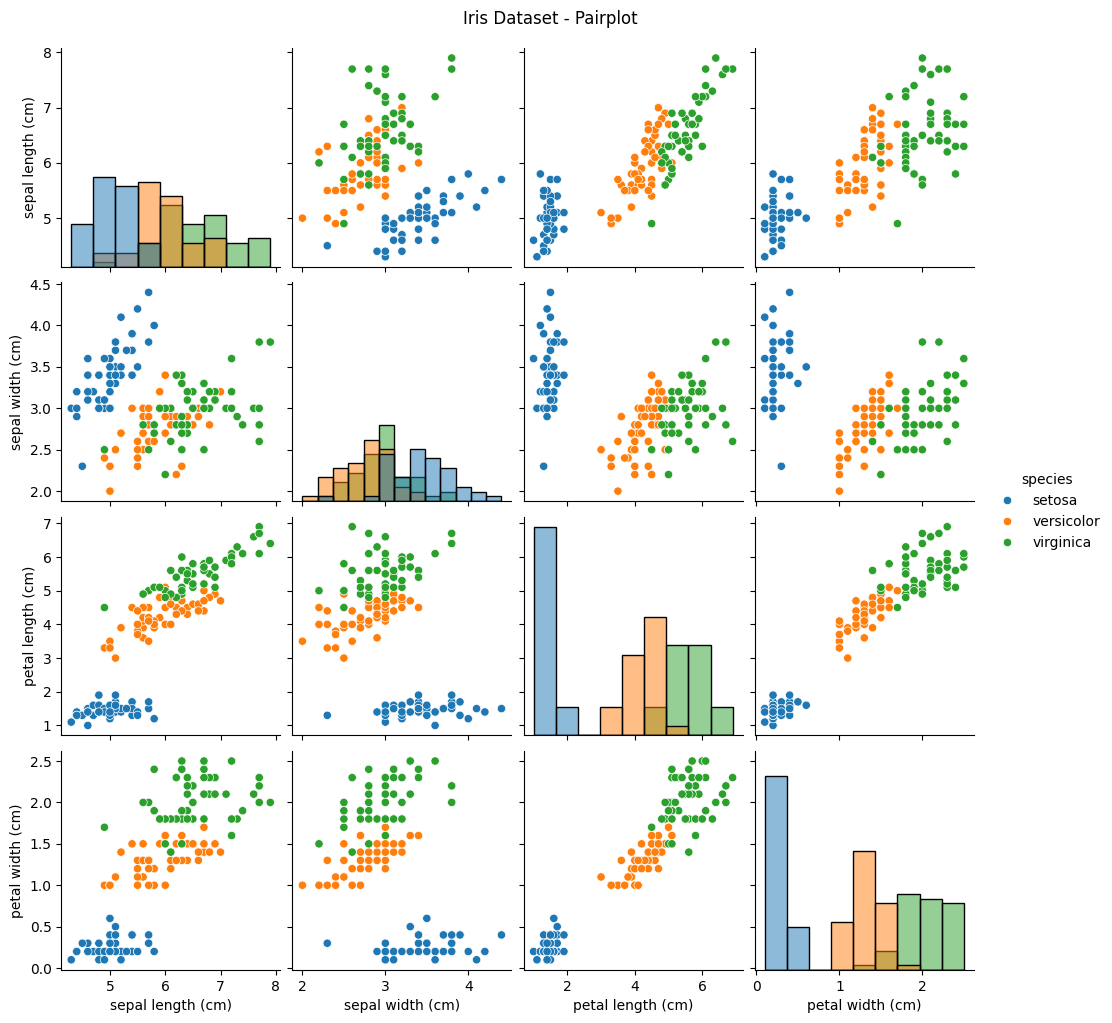

In [5]:
# Pairplot to visualize feature relationships
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Iris Dataset - Pairplot', y=1.02)
plt.show()

---
## 2. Split into Train and Test Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

Train size: 120 samples
Test size:  30 samples
Train class distribution: [40 40 40]
Test class distribution:  [10 10 10]


---
## 3. Train a Logistic Regression Classifier

In [7]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Actual:     ", y_test)

Predictions: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Actual:      [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9666666666666667

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



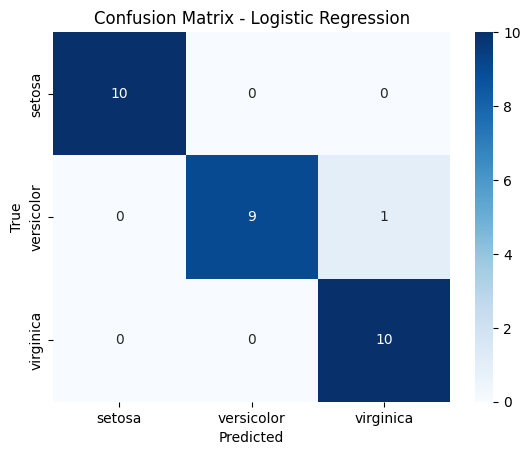

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

---
## 4. Feature Scaling

Many algorithms (SVM, KNN, Logistic Regression) perform better when features are on a similar scale.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original mean:", X_train.mean(axis=0).round(2))
print("Scaled mean:  ", X_train_scaled.mean(axis=0).round(2))
print("Scaled std:   ", X_train_scaled.std(axis=0).round(2))

Original mean: [5.84 3.05 3.77 1.2 ]
Scaled mean:   [-0. -0.  0.  0.]
Scaled std:    [1. 1. 1. 1.]


In [11]:
model_scaled = LogisticRegression(max_iter=200)
model_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy (scaled):", accuracy_score(y_test, y_pred_scaled))

Accuracy (scaled): 0.9333333333333333


---
## 5. Pipeline: Combine Preprocessing + Model

Using `make_pipeline` chains scaling and training into a single object — cleaner code and prevents data leakage.

In [12]:
pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=200))
pipeline.fit(X_train, y_train)

print("Pipeline test accuracy:", pipeline.score(X_test, y_test))

Pipeline test accuracy: 0.9333333333333333


---
## 6. Compare Multiple Classifiers

Experiment with different algorithms and compare their accuracy.

In [13]:
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(),
    'Random Forest':       RandomForestClassifier(),
    'Support Vector Mach': SVC(),
}

results = {}
for name, clf in classifiers.items():
    # Use pipeline with scaling for all
    pipe = make_pipeline(StandardScaler(), clf)
    scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
    results[name] = scores
    print(f"{name:25s} -> Accuracy: {scores.mean():.4f} (±{scores.std():.4f})")

Logistic Regression       -> Accuracy: 0.9600 (±0.0389)
K-Nearest Neighbors       -> Accuracy: 0.9600 (±0.0249)
Decision Tree             -> Accuracy: 0.9667 (±0.0365)
Random Forest             -> Accuracy: 0.9667 (±0.0211)
Support Vector Mach       -> Accuracy: 0.9667 (±0.0211)


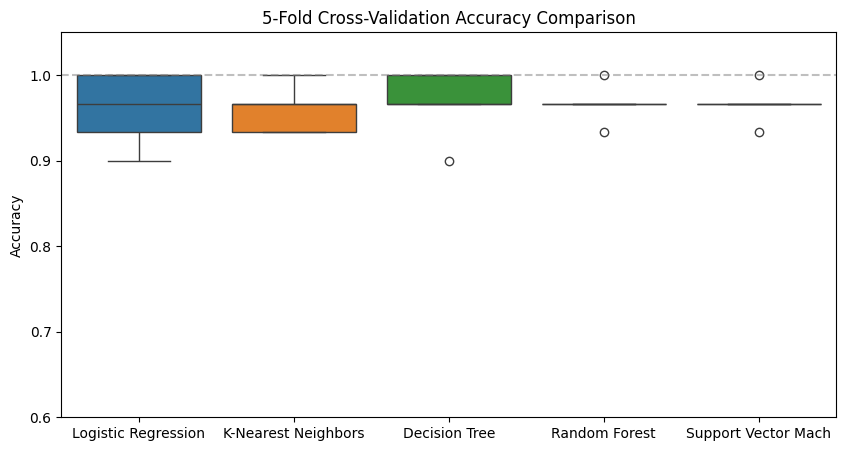

In [14]:
# Visualise comparison
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_results)
plt.title('5-Fold Cross-Validation Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.05)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.show()

---
## Summary

| Task | Class / Function |
|---|---|
| Load dataset | `sklearn.datasets.load_iris()` |
| Train/test split | `train_test_split()` |
| Feature scaling | `StandardScaler()` |
| Classification | `LogisticRegression()`, `KNeighborsClassifier()`, `DecisionTreeClassifier()`, `RandomForestClassifier()`, `SVC()` |
| Evaluation | `accuracy_score()`, `classification_report()`, `confusion_matrix()` |
| Pipeline | `make_pipeline()` |
| Cross-validation | `cross_val_score()` |

**Key takeaways:**
- Always split data before preprocessing to avoid data leakage.
- Scaling often improves model performance, especially for distance-based algorithms.
- Pipelines keep code clean and safe.
- Cross-validation gives a more reliable estimate of model performance than a single split.